In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [10]:
def merton_jump_paths(S, T, r, sigma,  lam, m, v, steps, Npaths):
    size=(steps,Npaths)
    dt = T/steps 

    poi_rv = np.multiply(np.random.poisson( lam*dt, size=size),
                         -np.random.exponential(scale=1, size=size)).cumsum(axis=0)

    geo = np.cumsum(((r -  sigma**2/2 -lam*(m  + v**2*0.5))*dt +\
                              sigma*np.sqrt(dt) * \
                              np.random.normal(size=size)), axis=0)
    
    return np.exp(geo+poi_rv)*S



def simulate_jump_diffusion(S_0,mu,sigma,lam, eta, T, steps, n_paths, seed):

    """
    Simulate paths with downward-only exponential jumps.
    Jump size Y = -Exp(eta)
    """

    if seed is not None:
        np.random.seed(seed)

    dt = T / steps
    drift = (mu - 0.5 * sigma**2) * dt
    diff_scale = sigma * np.sqrt(dt)

    S = np.zeros((steps + 1, n_paths))
    S[0] = S_0

    for t in range(1, steps + 1):
        # Diffusion part
        dW = np.random.randn(n_paths)
        diffusion = drift + diff_scale * dW

        # Jump arrivals
        J = np.random.poisson(lam * dt, n_paths)

        # Jump sizes (only where J > 0)
        jump_sizes = np.zeros(n_paths)
        jump_indices = J > 0
        if np.any(jump_indices):
            # Sum of J exponentials = Gamma(J, scale=1/eta)
            jump_sizes[jump_indices] = -np.random.gamma(
                shape=J[jump_indices],
                scale=1/eta
            )

        # Update log price
        S[t] = S[t-1] * np.exp(diffusion + jump_sizes)

    return S



S = 100 # current stock price
T = 1 # time to maturity
r = 0.02 # risk free rate
m = 0 # meean of jump size
v = 0.3 # standard deviation of jump
lam = 1 # intensity of jump i.e. number of jumps per annum
steps = 52 # time steps
Npaths = 10 # number of paths to simulate
sigma = 0.2 # annaul standard deviation , for weiner process

j = simulate_jump_diffusion(S_0=S, mu=0, sigma=sigma, lam=lam, eta=10, T=T, steps=steps, n_paths=Npaths, seed=43)

Text(0.5, 1.0, 'Jump Diffusion Process')

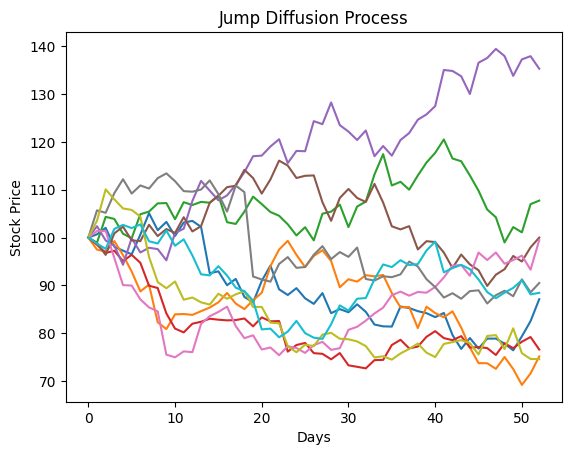

In [11]:
plt.plot(j)
plt.xlabel('Days')
plt.ylabel('Stock Price')
plt.title('Jump Diffusion Process')